## Kaggle Competition: [Mechanisms of Action (MoA) Prediction](https://www.kaggle.com/competitions/lish-moa/overview)

# Load data

In [2]:
! kaggle competitions download -c lish-moa
! unzip lish-moa.zip -d lish-moa

 99%|██████████████████████████████████████▌| 64.0M/64.7M [00:00<00:00, 664MB/s]
100%|███████████████████████████████████████| 64.7M/64.7M [00:00<00:00, 655MB/s]
Archive:  lish-moa.zip
  inflating: lish-moa/sample_submission.csv  
  inflating: lish-moa/test_features.csv  
  inflating: lish-moa/train_drug.csv  
  inflating: lish-moa/train_features.csv  
  inflating: lish-moa/train_targets_nonscored.csv  
  inflating: lish-moa/train_targets_scored.csv  


In [2]:
import pandas as pd


train_features = pd.read_csv("lish-moa/train_features.csv")
train_targets = pd.read_csv("lish-moa/train_targets_scored.csv")
train_drugs = pd.read_csv("lish-moa/train_drug.csv")
test_features = pd.read_csv("lish-moa/test_features.csv")
sample_submission = pd.read_csv("lish-moa/sample_submission.csv")

In [3]:
X_train = train_features.merge(train_drugs, on="sig_id", how="left") # extra column  "drug_id"
y_train = train_targets
X_test = test_features

# was idea to delete control group but it is also prsent in test set, so decided to keep it

# EDA

In [21]:
X_train.dtypes

X_train['cp_type'] = X_train['cp_type'].astype('category')
X_train['cp_dose'] = X_train['cp_dose'].astype('category')
X_train['cp_time'] = X_train['cp_time'].astype('category')
X_train['drug_id'] = X_train['drug_id'].astype('category')
drug_counts = X_train['drug_id'].value_counts()
print(drug_counts.head(10))

drug_id
cacb2b860    1866
87d714366     718
9f80f3f77     246
8b87a7a83     203
5628cb3ee     202
d08af5d4b     196
292ab2c28     194
d50f18348     186
d1b47f29d     178
67c879e79      19
Name: count, dtype: int64


## Categorical value

### Convert to categorical columns ['cp_type', 'cp_dose', 'cp_time', 'drug_id']

In [ ]:
X_train.dtypes

X_train['cp_type'] = X_train['cp_type'].astype('category')
X_train['cp_dose'] = X_train['cp_dose'].astype('category')
X_train['cp_time'] = X_train['cp_time'].astype('category')
X_train['drug_id'] = X_train['drug_id'].astype('category')
drug_counts = X_train['drug_id'].value_counts()
print(drug_counts.head(10))

drug_id
cacb2b860    1866
87d714366     718
9f80f3f77     246
8b87a7a83     203
5628cb3ee     202
d08af5d4b     196
292ab2c28     194
d50f18348     186
d1b47f29d     178
67c879e79      19
Name: count, dtype: int64


In [23]:
def convert_to_categorical(df):
    categorical_cols = ['cp_type', 'cp_dose', 'cp_time', 'drug_id']
    
    for col in categorical_cols:
        if col in df.columns:
            df[col] = df[col].astype('category')
    
    return df


In [24]:
X_train = convert_to_categorical(X_train)
X_test = convert_to_categorical(X_test)

In [ ]:
import altair as alt

def plot_categorical_distribution_altair(df, categorical_cols):
    for col in categorical_cols:
        if col in df.columns:
            counts = df[col].value_counts().reset_index()
            counts.columns = [col, 'count']
            
            chart = alt.Chart(counts).mark_bar().encode(
                x=alt.X(col, sort='-y'),
                y='count',
                color=col,
                tooltip=[col, 'count']
            ).properties(
                title=f'Distribution of {col}',
                width=400,
                height=300
            )
            chart.display()





In [43]:
categorical_cols = ['cp_type', 'cp_dose', 'cp_time']
plot_categorical_distribution_altair(X_train, categorical_cols)

alt.Chart(...)

alt.Chart(...)

alt.Chart(...)

In [42]:
import pandas as pd
import altair as alt

y_numeric = y_train.select_dtypes(include='number')


num_moas_per_experiment = (y_numeric > 0).sum(axis=1)


hist_df = pd.DataFrame({
    'num_moas': num_moas_per_experiment
})


hist_counts = hist_df['num_moas'].value_counts().reset_index()
hist_counts.columns = ['num_moas', 'num_experiments']
hist_counts = hist_counts.sort_values('num_moas')


chart = alt.Chart(hist_counts).mark_bar().encode(
    x=alt.X('num_moas:O', title='Number of MoAs per Experiment'),
    y=alt.Y('num_experiments:Q', title='Number of Experiments'),
    tooltip=['num_moas', 'num_experiments'],
    color='num_experiments:Q'
).properties(
    width=800,
    height=400,
    title='Distribution of Experiments by Number of MoAs'
).interactive()

chart.display()


alt.Chart(...)

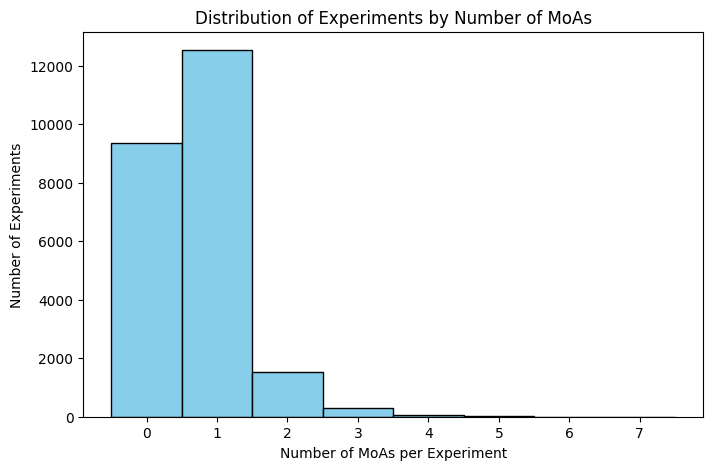

In [41]:
import matplotlib.pyplot as plt

# Keep only numeric columns (0/1 MoA targets)
y_numeric = y_train.select_dtypes(include='number')

# Count number of MoAs per experiment (row)
num_moas_per_experiment = (y_numeric > 0).sum(axis=1)

# Plot histogram
plt.figure(figsize=(8,5))
plt.hist(num_moas_per_experiment, bins=range(num_moas_per_experiment.max()+2),
         color='skyblue', edgecolor='black', align='left')
plt.xlabel('Number of MoAs per Experiment')
plt.ylabel('Number of Experiments')
plt.title('Distribution of Experiments by Number of MoAs')
plt.xticks(range(num_moas_per_experiment.max()+1))
plt.show()


## Continuous  value

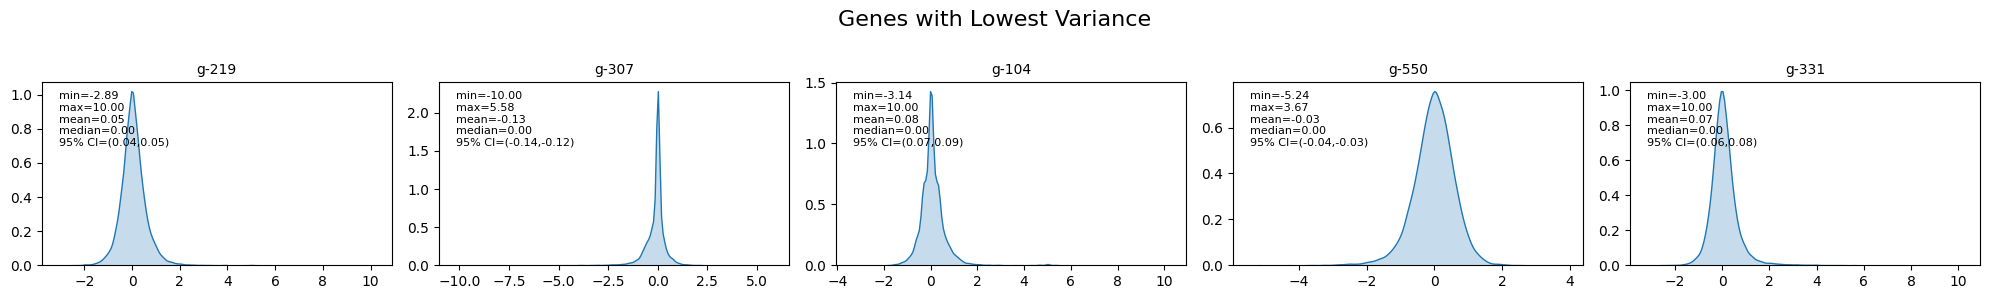

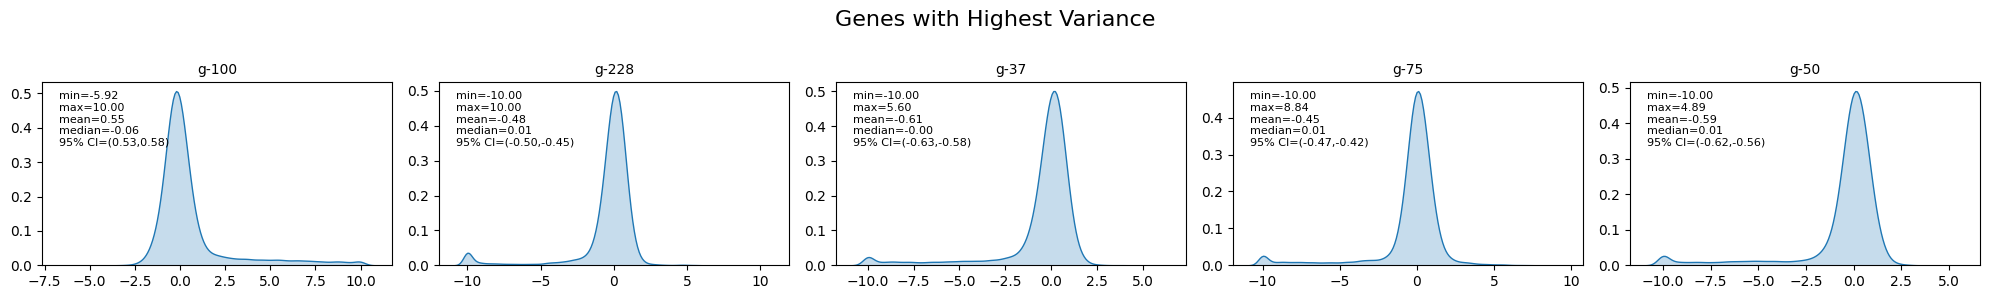

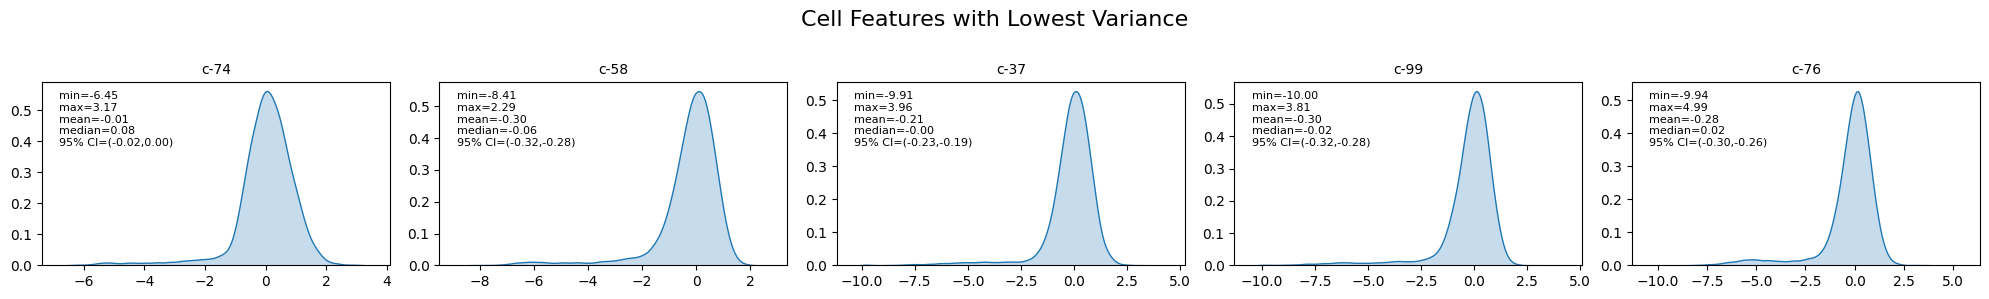

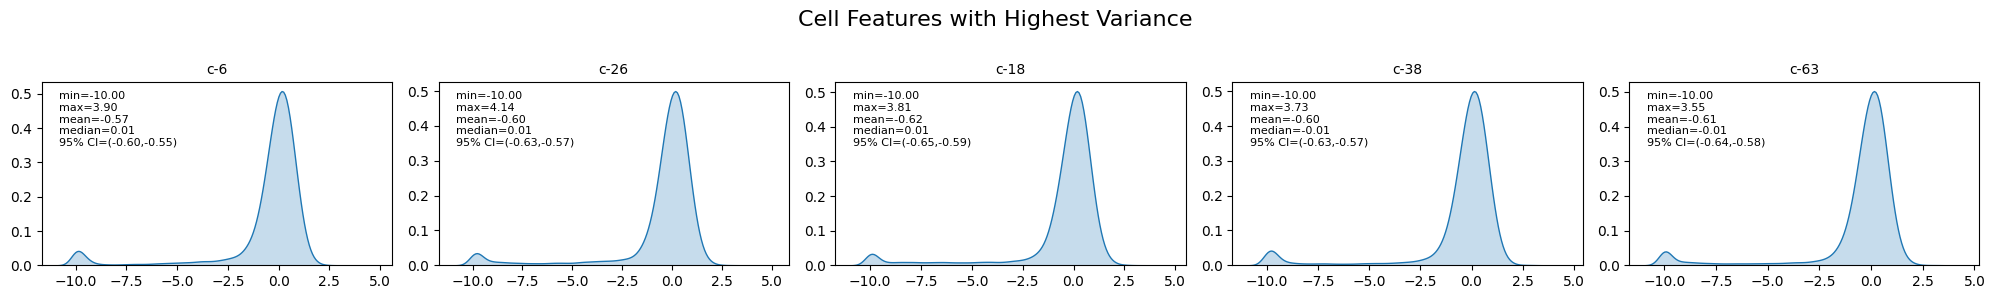

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

gene_cols = [col for col in X_train.columns if col.startswith('g-')]
cell_cols = [col for col in X_train.columns if col.startswith('c-')]

gene_variance = X_train[gene_cols].var().sort_values()
cell_variance = X_train[cell_cols].var().sort_values()



def plot_density(df, features, title):
    n = len(features)
    n_cols = 5
    n_rows = (n + n_cols - 1) // n_cols

    plt.figure(figsize=(n_cols*4, n_rows*3))
    
    for i, col in enumerate(features):
        plt.subplot(n_rows, n_cols, i+1)
        sns.kdeplot(df[col], fill=True)
        
        mean = df[col].mean()
        median = df[col].median()
        min_val = df[col].min()
        max_val = df[col].max()
        ci_low, ci_high = stats.t.interval(
            0.95, len(df[col])-1, loc=mean, scale=stats.sem(df[col])
        )
        stats_text = f"min={min_val:.2f}\nmax={max_val:.2f}\nmean={mean:.2f}\nmedian={median:.2f}\n95% CI=({ci_low:.2f},{ci_high:.2f})"
        plt.title(col, fontsize=10)
        plt.xlabel('')
        plt.ylabel('')
        plt.text(0.05, 0.95, stats_text, transform=plt.gca().transAxes,
                 fontsize=8, verticalalignment='top')
        
    plt.suptitle(title, fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()


plot_density(X_train, gene_variance.head(5).index.tolist(), "Genes with Lowest Variance")
plot_density(X_train, gene_variance.tail(5).index.tolist(), "Genes with Highest Variance")
plot_density(X_train, cell_variance.head(5).index.tolist(), "Cell Features with Lowest Variance")
plot_density(X_train, cell_variance.tail(5).index.tolist(), "Cell Features with Highest Variance")


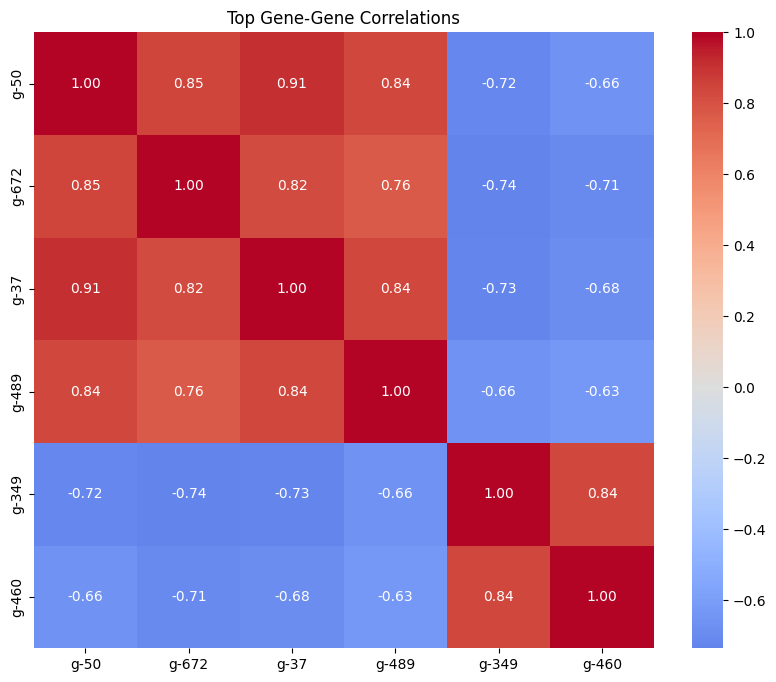

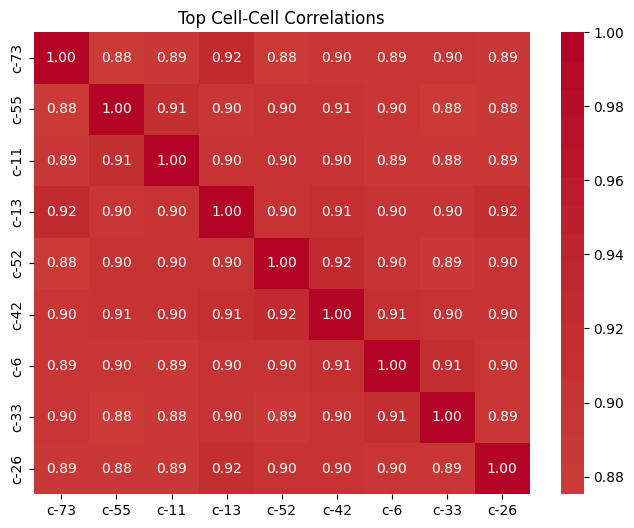

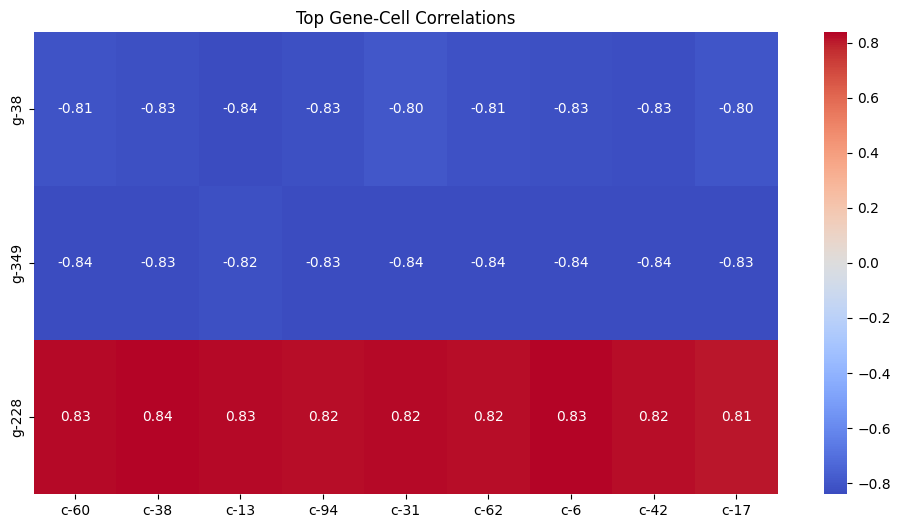

In [12]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


gene_corr = X_train[gene_cols].corr()
cell_corr = X_train[cell_cols].corr()
gene_cell_corr = X_train[gene_cols + cell_cols].corr().loc[gene_cols, cell_cols]


def top_corr_pairs(corr_df, top_n=10, exclude_self=True):
    corr_abs = corr_df.abs()
    if exclude_self and corr_df.shape[0]==corr_df.shape[1]: 
        np.fill_diagonal(corr_abs.values, 0)
    stacked = corr_abs.stack().sort_values(ascending=False)
    return stacked.head(top_n)


top_gene_gene_pairs = top_corr_pairs(gene_corr)
top_cell_cell_pairs = top_corr_pairs(cell_corr)
top_gene_cell_pairs = gene_cell_corr.abs().stack().sort_values(ascending=False).head(10)


def subset_corr_matrix(corr_df, pairs):
    features = list(set([i for i,j in pairs.index] + [j for i,j in pairs.index]))
    return corr_df.loc[features, features]

gene_gene_matrix = subset_corr_matrix(gene_corr, top_gene_gene_pairs)
cell_cell_matrix = subset_corr_matrix(cell_corr, top_cell_cell_pairs)


plt.figure(figsize=(10,8))
sns.heatmap(gene_gene_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Top Gene-Gene Correlations")
plt.show()

plt.figure(figsize=(8,6))
sns.heatmap(cell_cell_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Top Cell-Cell Correlations")
plt.show()

gene_cell_features = list(set([i for i,j in top_gene_cell_pairs.index] + [j for i,j in top_gene_cell_pairs.index]))
gene_features = [f for f in gene_cell_features if f in gene_cols]
cell_features = [f for f in gene_cell_features if f in cell_cols]
gene_cell_matrix_subset = gene_cell_corr.loc[gene_features, cell_features]

plt.figure(figsize=(12,6))
sns.heatmap(gene_cell_matrix_subset, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Top Gene-Cell Correlations")
plt.show()


### Dependency between categorical and continous features. (try all categorcal combination with UMAP,T-SNE and PCA - left just +- some clustures )

/Users/annanechytailenko/Desktop/Assignment01_DP/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


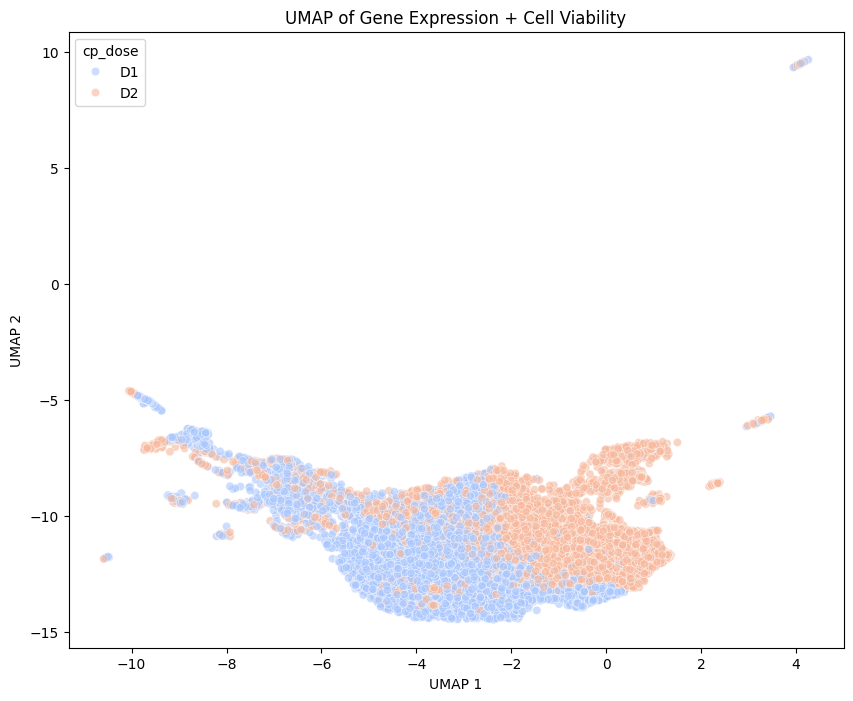

In [33]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import umap.umap_ as umap

import matplotlib.pyplot as plt
import seaborn as sns


gene_cols = [col for col in X_train.columns if col.startswith('g-')]
cell_cols = [col for col in X_train.columns if col.startswith('c-')]


features = gene_cols + cell_cols ## ACTUALLY REDUNDANT !!!
X = X_train[features]


X_scaled = StandardScaler().fit_transform(X)


reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=30, min_dist=0.1)
X_umap = reducer.fit_transform(X_scaled)


umap_df = pd.DataFrame({
    'UMAP1': X_umap[:,0],
    'UMAP2': X_umap[:,1],
    'cp_dose': X_train['cp_dose'],
    'drug_id': X_train['drug_id']
})


plt.figure(figsize=(10,8))
sns.scatterplot(
    data=umap_df,
    x='UMAP1',
    y='UMAP2',
    hue='cp_dose',        
    palette='coolwarm',
    alpha=0.6
)
plt.title('UMAP of Gene Expression + Cell Viability')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.legend(title='cp_dose')
plt.show()


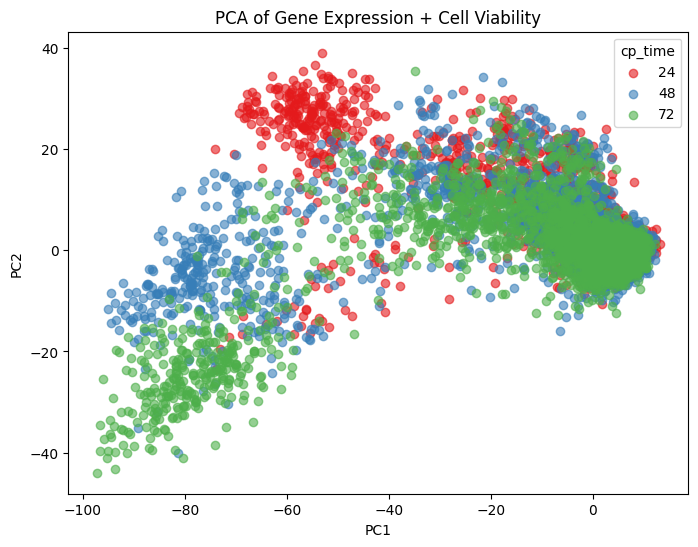

In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd


gene_cols = [col for col in X_train.columns if col.startswith('g-')]
cell_cols = [col for col in X_train.columns if col.startswith('c-')]
features = gene_cols + cell_cols ## ACTUALLY REDUNDANT !!!
X = X_train[features]


X_scaled = StandardScaler().fit_transform(X)


pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


categories = pd.Categorical(X_train['cp_time']).categories
category_colors = plt.cm.Set1(range(len(categories)))  
category_map = dict(zip(categories, category_colors))

plt.figure(figsize=(8,6))
for cat in categories:
    idx = X_train['cp_time'] == cat
    plt.scatter(X_pca[idx,0], X_pca[idx,1], 
                color=category_map[cat], label=str(cat), alpha=0.6)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA of Gene Expression + Cell Viability')
plt.legend(title='cp_time')
plt.show()


# Baseline tree based models

### DecisionTree 

### Random Forest

### GBMS

### DP

### Random Notes:
-Group vlidation based  on the true label

cosani — better use **ReduceLROnPlateau**

### (a) **Inverted dropout** (most used):

- At training time: when a neuron is active, divide its activation by ppp.
- At test time: do **nothing**, because activations are already scaled correctly.

Formula:

h′={0with probability 1−phpwith probability ph' =
\begin{cases}
0 & \text{with probability } 1 - p \\
\frac{h}{p} & \text{with probability } p
\end{cases}

h′={0phwith probability 1−pwith probability p

### (b) **Classical dropout** (older):

- At training time: just drop neurons without scaling.
- At test time: multiply all activations by ppp.

✅ **Summary Flow**

- **BatchNorm**: normalize per neuron across the batch.
- **LayerNorm**: normalize per sample across its features.

aggressive validation